Parameter_Space_Figure4

In [1]:
import numpy as np
import xarray as xr
from xso.parscans import run_xso_parscan, run_xso_stabilityscan

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm

In [2]:
higherordermortality = np.linspace(0.01,0.03, 50)
ivp_param_values = [np.array([0, 0, 0, val]) for val in higherordermortality]
ivp_param_values2 = np.linspace(0.3,0.4, 50)

In [3]:
stability_results = run_xso_stabilityscan(
    model_file_name='Stocketal2008',
    model_setup_name='model_setup_stability',
    param_name='HigherOrderMortality__rate',
    param_values=ivp_param_values,
    param_name2='GGE__gge',
    param_values2=ivp_param_values2,
    processes=20
)

print("\nStability data:")
print(stability_results['stability'])

PROGRESS: Completed 50/50 outer points. (HigherOrderMortality__rate = [0.   0.   0.   0.03]).

2D Stability Scan complete. Total Time taken: 12.49293 seconds.

Stability data:
<xarray.DataArray 'stability' (GGE__gge: 50, HigherOrderMortality__rate: 50)> Size: 20kB
array([['unstable', 'unstable', 'unstable', ..., 'unstable', 'unstable',
        'unstable'],
       ['unstable', 'unstable', 'unstable', ..., 'unstable', 'unstable',
        'unstable'],
       ['unstable', 'unstable', 'unstable', ..., 'unstable', 'unstable',
        'unstable'],
       ...,
       [nan, nan, 'unstable', ..., 'unstable', 'unstable', 'unstable'],
       [nan, nan, 'unstable', ..., 'unstable', 'unstable', 'unstable'],
       [nan, 'unstable', 'unstable', ..., 'unstable', 'unstable',
        'unstable']], shape=(50, 50), dtype=object)
Coordinates:
  * GGE__gge                    (GGE__gge) float64 400B 0.3 0.302 ... 0.398 0.4
  * HigherOrderMortality__rate  (HigherOrderMortality__rate) float64 400B 0.0...


In [8]:
def plot_stability_heatmap(ds, title='Model Stability across Parameter Space'):
    """
    Plot stability heatmap from stability scan results
    
    Parameters:
    -----------
    ds : xarray.Dataset
        Output from stability scan containing 'stability' variable
    title : str
        Title for the plot
    """
    def stability_to_numeric(data):
        """Convert stability strings to numeric values"""
        stability_num = xr.full_like(data['stability'], np.nan, dtype=float)
        stability_num = stability_num.where(data['stability'] != 'stable', 1)
        stability_num = stability_num.where(data['stability'] != 'unstable', -1)
        stability_num = stability_num.where(data['stability'] != 'marginally_stable', 0)
        # NaN values remain as NaN (failed convergence)
        return stability_num
    
    # Create the heatmap
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    
    # Convert stability to numeric
    stability_numeric = stability_to_numeric(ds)
    
    # Create the heatmap
    im = ax.pcolormesh(
        ds['GGE__gge'], 
        ds['HigherOrderMortality__rate'],
        stability_numeric.T,
        cmap='RdYlGn',
        vmin=-1, vmax=1,
        shading='nearest'
    )
    
    # Add colorbar with custom labels
    cbar = plt.colorbar(im, ax=ax, ticks=[-1, 0, 1])
    cbar.ax.set_yticklabels(['Unstable', 'Marginally\nStable', 'Stable'])
    
    # Labels and title
    ax.set_xlabel('Gross Growth Efficiency')
    ax.set_ylabel('Higher Order Mortality')
    ax.set_title(title)
    
    # Add grid for clarity
    ax.set_xticks(ds['GGE__gge'])
    ax.set_yticks(ds['HigherOrderMortality__rate'])
    ax.grid(True, alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    plt.show()
    
    return fig, ax

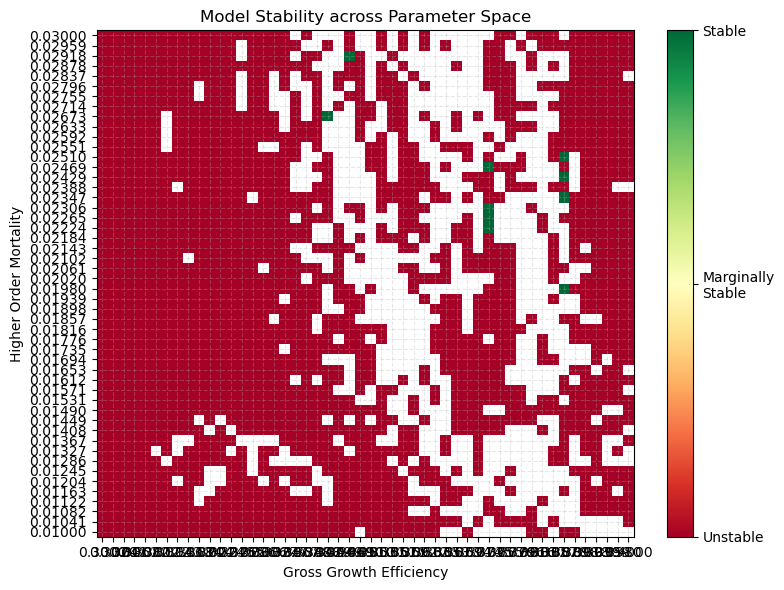

(<Figure size 800x600 with 2 Axes>,
 <Axes: title={'center': 'Model Stability across Parameter Space'}, xlabel='Gross Growth Efficiency', ylabel='Higher Order Mortality'>)

In [9]:
plot_stability_heatmap(stability_results)

# Let's check IVP solver results to find stable runs and check those against this!

In [10]:
ivp_results = run_xso_parscan(
    model_file_name='Stocketal2008',
    model_setup_name='model_setup_ivp', 
    param_name='HigherOrderMortality__rate',
    param_values=ivp_param_values,       
    param_name2='GGE__gge',
    param_values2=ivp_param_values2,     
    processes=20
)

PROGRESS: Completed 50/50 outer points. (HigherOrderMortality__rate = [0.   0.   0.   0.03]).

2D Scan complete. Total Time taken: 430.14057 seconds.


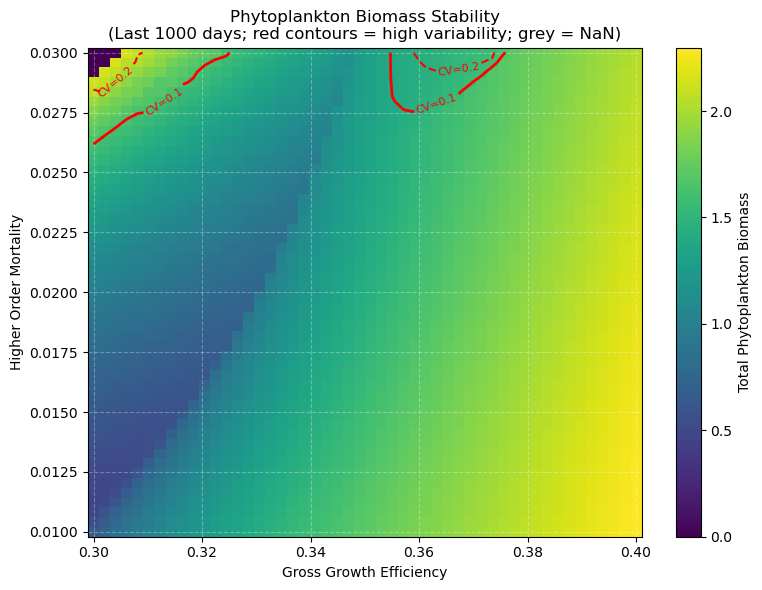

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm

# Extract last 1000 days of phytoplankton biomass
phyto_last1000 = ivp_results['Phytoplankton__biomass'].isel(time=slice(-1000, None))

# Sum across phytoplankton size classes
phyto_total = phyto_last1000.sum(dim='phyto')

# Calculate mean and std over the last 1000 days
phyto_mean = phyto_total.mean(dim='time')
phyto_std = phyto_total.std(dim='time')

# Calculate coefficient of variation (std/mean) as stability metric
phyto_cv = phyto_std / phyto_mean

# Create the plot
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# Set up colormap with grey for NaN
cmap = plt.colormaps['viridis'].copy()
cmap.set_bad(color='grey', alpha=0.5)

# Plot mean biomass with custom colormap
im = ax.pcolormesh(
    ivp_results['GGE__gge'], 
    ivp_results['HigherOrderMortality__rate'],
    phyto_mean.T,
    cmap=cmap,
    shading='nearest'
)

# Overlay contours for high variability regions (CV > threshold)
cv_threshold = 0.1  # Adjust this threshold as needed
contour = ax.contour(
    ivp_results['GGE__gge'], 
    ivp_results['HigherOrderMortality__rate'],
    phyto_cv.T,
    levels=[cv_threshold, 0.2, 0.5],  # Multiple contour levels
    colors='red',
    linewidths=[2, 1.5, 1],
    linestyles=['solid', 'dashed', 'dotted']
)
ax.clabel(contour, inline=True, fontsize=8, fmt='CV=%.1f')

# Add colorbar for biomass
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Total Phytoplankton Biomass')

# Labels and title
ax.set_xlabel('Gross Growth Efficiency')
ax.set_ylabel('Higher Order Mortality')
ax.set_title('Phytoplankton Biomass Stability\n(Last 1000 days; red contours = high variability; grey = NaN)')

# Add grid
ax.grid(True, alpha=0.3, linestyle='--', color='white')

plt.tight_layout()
plt.show()

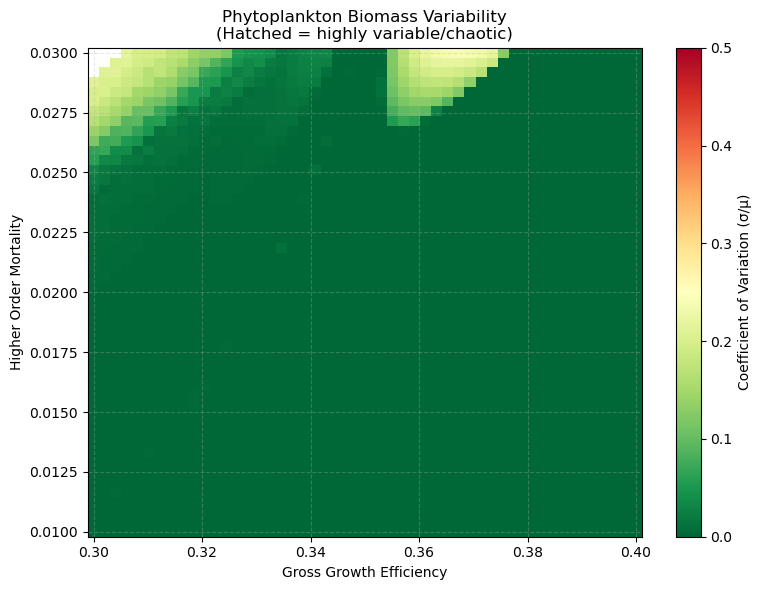

In [12]:
# Alternative plot focusing on stability metric
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# Plot coefficient of variation directly
im = ax.pcolormesh(
    ivp_results['GGE__gge'], 
    ivp_results['HigherOrderMortality__rate'],
    phyto_cv.T,
    cmap='RdYlGn_r',  # Reversed: red=unstable, green=stable
    vmin=0, vmax=0.5,  # Adjust based on your data range
    shading='nearest'
)

# Mark regions with very high std (potentially chaotic)
high_std_mask = phyto_cv > 0.3  # Adjust threshold
ax.contourf(
    ivp_results['GGE__gge'], 
    ivp_results['HigherOrderMortality__rate'],
    high_std_mask.T,
    levels=[0.5, 1.5],
    colors='none',
    hatches=['///'],
    alpha=0
)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Coefficient of Variation (σ/μ)')

ax.set_xlabel('Gross Growth Efficiency')
ax.set_ylabel('Higher Order Mortality')
ax.set_title('Phytoplankton Biomass Variability\n(Hatched = highly variable/chaotic)')

ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

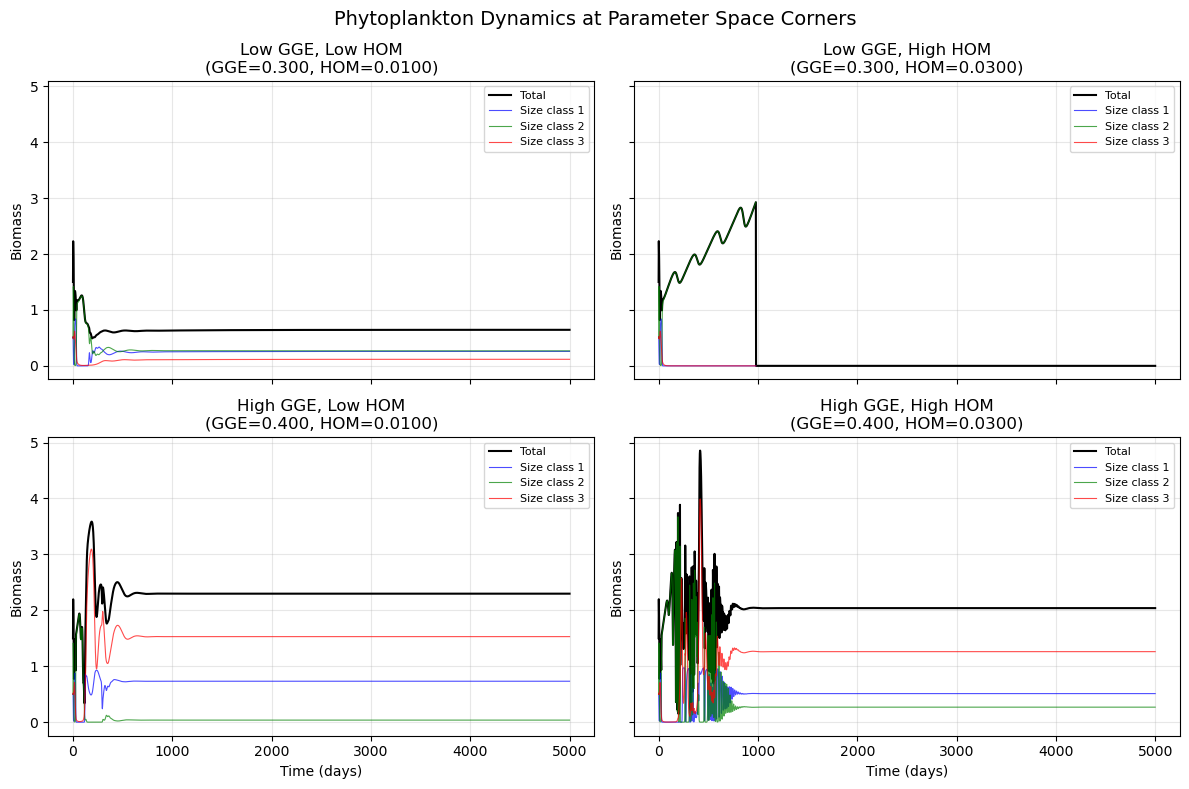

In [13]:
import matplotlib.pyplot as plt

# Extract phytoplankton biomass for the four corners
corners = {
    'Low GGE, Low HOM': ivp_results['Phytoplankton__biomass'].isel(GGE__gge=0, HigherOrderMortality__rate=0),
    'Low GGE, High HOM': ivp_results['Phytoplankton__biomass'].isel(GGE__gge=0, HigherOrderMortality__rate=-1),
    'High GGE, Low HOM': ivp_results['Phytoplankton__biomass'].isel(GGE__gge=-1, HigherOrderMortality__rate=0),
    'High GGE, High HOM': ivp_results['Phytoplankton__biomass'].isel(GGE__gge=-1, HigherOrderMortality__rate=-1)
}

# Create 2x2 subplot
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.flatten()

for ax, (label, data) in zip(axes, corners.items()):
    # Sum across phytoplankton size classes
    total_biomass = data.sum(dim='phyto')
    
    # Plot total biomass
    ax.plot(ivp_results['time'], total_biomass, label='Total', color='black', linewidth=1.5)
    
    # Plot individual size classes
    colors = ['blue', 'green', 'red']
    for i, color in enumerate(colors):
        ax.plot(ivp_results['time'], data.isel(phyto=i), 
                label=f'Size class {i+1}', color=color, alpha=0.7, linewidth=0.8)
    
    # Get parameter values for title
    gge_val = ivp_results['GGE__gge'].values[0 if 'Low GGE' in label else -1]
    hom_val = ivp_results['HigherOrderMortality__rate'].values[0 if 'Low HOM' in label else -1]
    
    ax.set_title(f'{label}\n(GGE={gge_val:.3f}, HOM={hom_val:.4f})')
    ax.set_ylabel('Biomass')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right', fontsize=8)

# Set common x-label
for ax in axes[-2:]:
    ax.set_xlabel('Time (days)')

plt.suptitle('Phytoplankton Dynamics at Parameter Space Corners', fontsize=14)
plt.tight_layout()
plt.show()

In [14]:
ivp_results['Phytoplankton__biomass'].isel(GGE__gge=0, HigherOrderMortality__rate=0)

<xarray.DataArray 'Phytoplankton__biomass' (phyto: 3, time: 5000)> Size: 120kB
array([[0.5       , 0.52093033, 0.40237522, ..., 0.25901219, 0.25901223,
        0.25901231],
       [0.5       , 0.97265285, 1.30653701, ..., 0.26803957, 0.26803968,
        0.26803976],
       [0.5       , 0.52177676, 0.51891453, ..., 0.11725533, 0.11725538,
        0.11725543]], shape=(3, 5000))
Coordinates:
  * phyto                       (phyto) float64 24B 0.63 6.3 63.0
  * time                        (time) float64 40kB 0.0 1.0 ... 4.999e+03
    GGE__gge                    float64 8B 0.3
    HigherOrderMortality__rate  float64 8B 0.01
Attributes:
    description:    output of variable / phytoplankton biomass
    long_name:      Phytoplankton biomass concentration
    standard_name:  Phytoplankton
    units:          mmol N m-3
    xso_store_out:  True

In [15]:
from func_parallel import run_model_test_stability

In [16]:
test_output_stability = run_model_test_stability(
    {'GGE__gge':0.3,'HigherOrderMortality__rate': 0.01}
)

[INFO] Initial state dimension: 8
[INFO] Initial state: [1.  0.5 0.5 0.5 0.1 0.1 0.1 0.1]
[INFO] Steady state found with residual norm: 2.22e-13
  Steady state: [ 1.13477601e+00  9.90122166e-14 -6.83952444e-16  1.33286572e-01
  1.66429104e-03 -6.98109003e-11  3.06122449e-01  1.28918919e-01]
[INFO] Computing Jacobian numerically...
[INFO] Successfully computed 8 eigenvalues


In [17]:
IVPOUT_testing = ivp_results.isel(GGE__gge=0, HigherOrderMortality__rate=0)

mean_out_testing = IVPOUT_testing[['Nutrient__value','Phytoplankton__biomass', 'Zooplankton__biomass']] \
                         .isel(time=slice(-1000, None)) \
                         .mean(dim='time')

In [18]:
test_output_stability = run_model_test_stability(
    {'Nutrient__value_init':mean_out_testing.Nutrient__value.values,
    'Phytoplankton__biomass_init':mean_out_testing.Phytoplankton__biomass.values,
    'Zooplankton__biomass_init':mean_out_testing.Zooplankton__biomass.values,
    'GGE__gge':0.3,'HigherOrderMortality__rate': 0.01}
)


[INFO] Initial state dimension: 8
[INFO] Initial state: [0.20051807 0.25896652 0.26805855 0.11721547 0.16453179 0.45771806
 0.30613226 0.4123656 ]
[INFO] Steady state found with residual norm: 9.78e-11
  Steady state: [0.30770524 0.37692008 0.23498976 0.25699741 0.15377777 0.60796191
 0.30612245 0.54653745]
[INFO] Computing Jacobian numerically...
[INFO] Successfully computed 8 eigenvalues


# NOW lets initialize the fsolve parscan with ivp_solver output!

In [19]:
mean_results = ivp_results[['Nutrient__value','Phytoplankton__biomass', 'Zooplankton__biomass']] \
                         .isel(time=slice(-1000, None)) \
                         .mean(dim='time')

mean_results

<xarray.Dataset> Size: 161kB
Dimensions:                     (GGE__gge: 50, HigherOrderMortality__rate: 50,
                                 phyto: 3, zoo: 4)
Coordinates:
  * GGE__gge                    (GGE__gge) float64 400B 0.3 0.302 ... 0.398 0.4
  * HigherOrderMortality__rate  (HigherOrderMortality__rate) float64 400B 0.0...
  * phyto                       (phyto) float64 24B 0.63 6.3 63.0
  * zoo                         (zoo) float64 32B 6.3 63.0 630.0 6.3e+03
Data variables:
    Nutrient__value             (GGE__gge, HigherOrderMortality__rate) float64 20kB ...
    Phytoplankton__biomass      (GGE__gge, HigherOrderMortality__rate, phyto) float64 60kB ...
    Zooplankton__biomass        (GGE__gge, HigherOrderMortality__rate, zoo) float64 80kB ...

In [20]:
iv_map = {
    'Nutrient__value': 'Nutrient__value_init',
    'Phytoplankton__biomass':'Phytoplankton__biomass_init',
    'Zooplankton__biomass':'Zooplankton__biomass_init'
}

stability_results_initcond = run_xso_stabilityscan(
    model_file_name='Stocketal2008',
    model_setup_name='model_setup_stability',
    param_name='HigherOrderMortality__rate',
    param_values=ivp_param_values,
    param_name2='GGE__gge',
    param_values2=ivp_param_values2,
    processes=20,
    initial_values_ds=mean_results,      # <-- Pass the mean results
    iv_mapping=iv_map                    # <-- Pass the name mapping
)

print("\nStability data:")
print(stability_results['stability'])

PROGRESS: Completed 50/50 outer points. (HigherOrderMortality__rate = [0.   0.   0.   0.03]).

2D Stability Scan complete. Total Time taken: 9.78699 seconds.

Stability data:
<xarray.DataArray 'stability' (GGE__gge: 50, HigherOrderMortality__rate: 50)> Size: 20kB
array([['unstable', 'unstable', 'unstable', ..., 'unstable', 'unstable',
        'unstable'],
       ['unstable', 'unstable', 'unstable', ..., 'unstable', 'unstable',
        'unstable'],
       ['unstable', 'unstable', 'unstable', ..., 'unstable', 'unstable',
        'unstable'],
       ...,
       [nan, nan, 'unstable', ..., 'unstable', 'unstable', 'unstable'],
       [nan, nan, 'unstable', ..., 'unstable', 'unstable', 'unstable'],
       [nan, 'unstable', 'unstable', ..., 'unstable', 'unstable',
        'unstable']], shape=(50, 50), dtype=object)
Coordinates:
  * GGE__gge                    (GGE__gge) float64 400B 0.3 0.302 ... 0.398 0.4
  * HigherOrderMortality__rate  (HigherOrderMortality__rate) float64 400B 0.0...


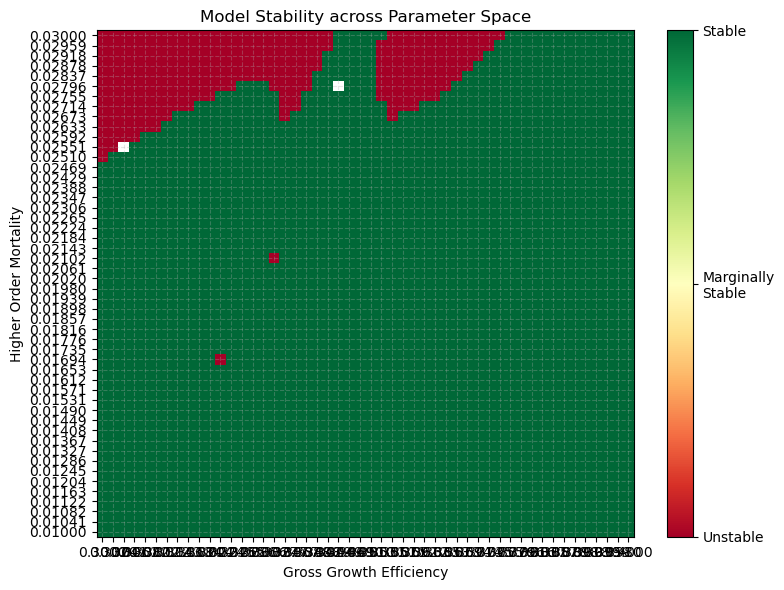

(<Figure size 800x600 with 2 Axes>,
 <Axes: title={'center': 'Model Stability across Parameter Space'}, xlabel='Gross Growth Efficiency', ylabel='Higher Order Mortality'>)

In [21]:
plot_stability_heatmap(stability_results_initcond)

In [24]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from scipy import ndimage

def plot_stability_with_boundaries(ds, title='Model Stability with Bifurcation Boundaries'):
    """
    Plot stability heatmap with bifurcation boundaries highlighted
    
    Parameters:
    -----------
    ds : xarray.Dataset
        Output from stability scan containing 'stability' variable
    title : str
        Title for the plot
    """
    def stability_to_numeric(data):
        """Convert stability strings to numeric values"""
        stability_num = xr.full_like(data['stability'], np.nan, dtype=float)
        stability_num = stability_num.where(data['stability'] != 'stable', 1)
        stability_num = stability_num.where(data['stability'] != 'unstable', -1)
        stability_num = stability_num.where(data['stability'] != 'marginally_stable', 0)
        return stability_num
    
    # Create the heatmap
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    
    # Convert stability to numeric
    stability_numeric = stability_to_numeric(ds)
    
    # Create the heatmap
    im = ax.pcolormesh(
        ds['GGE__gge'], 
        ds['HigherOrderMortality__rate'],
        stability_numeric.T,
        cmap='RdYlGn',
        vmin=-1, vmax=1,
        shading='nearest'
    )
    
    # Find bifurcation boundaries using edge detection
    stability_array = stability_numeric.values.T
    
    # Create binary mask for stable regions (1 where stable, 0 elsewhere)
    stable_mask = np.where(stability_array == 1, 1, 0)
    unstable_mask = np.where(stability_array == -1, 1, 0)
    
    # Find edges using gradient (boundaries between stable/unstable)
    # Use Sobel filter to find edges
    from scipy.ndimage import sobel
    edges_x = sobel(stable_mask, axis=0)
    edges_y = sobel(stable_mask, axis=1)
    edges = np.hypot(edges_x, edges_y)
    
    # Plot boundaries as contours
    X, Y = np.meshgrid(ds['GGE__gge'].values, ds['HigherOrderMortality__rate'].values)
    
    # Add boundary contours
    boundary_contour = ax.contour(
        X, Y, edges,
        levels=[0.5],  # Single contour at edge threshold
        colors='black',
        linewidths=2,
        linestyles='solid'
    )
    
    # Optionally, add contours from max eigenvalue if available
    if 'max_eigenvalue' in ds:
        eigenvalue_contour = ax.contour(
            X, Y, ds['max_eigenvalue'].T,
            levels=[0],  # Zero eigenvalue = bifurcation
            colors='blue',
            linewidths=1.5,
            linestyles='dashed',
            alpha=0.7
        )
        ax.clabel(eigenvalue_contour, inline=True, fontsize=8, fmt='λ=0')
    
    # Add colorbar with custom labels
    cbar = plt.colorbar(im, ax=ax, ticks=[-1, 0, 1])
    cbar.ax.set_yticklabels(['Unstable', 'Marginally\nStable', 'Stable'])
    
    # Labels and title
    ax.set_xlabel('Gross Growth Efficiency')
    ax.set_ylabel('Higher Order Mortality')
    ax.set_title(title)
    
    # Add grid for clarity
    ax.set_xticks(ds['GGE__gge'])
    ax.set_yticks(ds['HigherOrderMortality__rate'])
    ax.grid(True, alpha=0.3, linestyle='--')
    
    # Add legend for boundaries
    ax.plot([], [], 'k-', linewidth=2, label='Stability boundary')
    if 'max_eigenvalue' in ds:
        ax.plot([], [], 'b--', linewidth=1.5, label='λ=0 contour')
    ax.legend(loc='upper right', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    return fig, ax

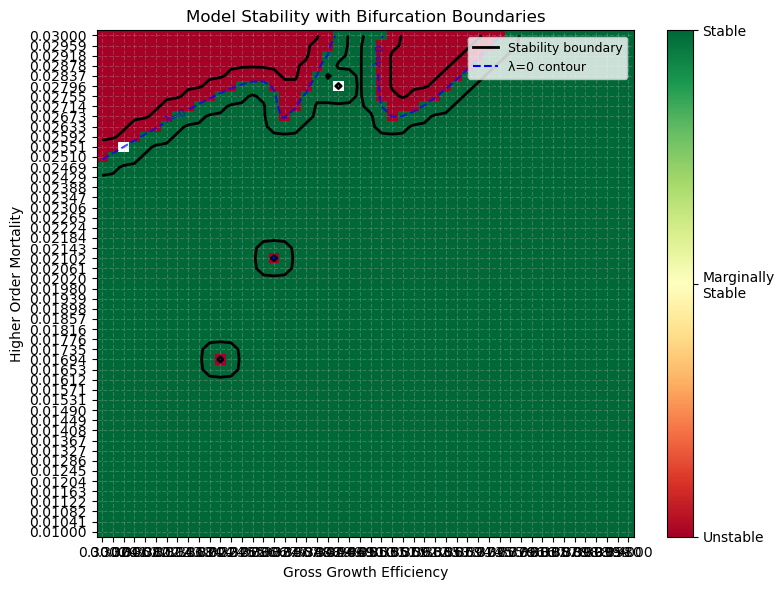

(<Figure size 800x600 with 2 Axes>,
 <Axes: title={'center': 'Model Stability with Bifurcation Boundaries'}, xlabel='Gross Growth Efficiency', ylabel='Higher Order Mortality'>)

In [25]:
plot_stability_with_boundaries(stability_results_initcond)

In [28]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import griddata

def plot_bifurcation_from_eigenvalues(ds, ivp_results=None, title='Bifurcation Analysis'):
    """
    Plot mathematically rigorous bifurcation boundaries using eigenvalues
    """
    fig, ax = plt.subplots(1, 1, figsize=(10, 7))
    
    # Plot max eigenvalue field
    max_eig = ds['max_eigenvalue'].values.T
    
    # Create mesh
    X, Y = np.meshgrid(ds['GGE__gge'].values, ds['HigherOrderMortality__rate'].values)
    
    # Plot eigenvalue field with diverging colormap centered at 0
    im = ax.pcolormesh(
        X, Y, max_eig,
        cmap='RdBu_r',  # Red for positive (unstable), Blue for negative (stable)
        vmin=-np.nanmax(np.abs(max_eig)), 
        vmax=np.nanmax(np.abs(max_eig)),
        shading='nearest'
    )
    
    # TRUE BIFURCATION: Contour at max eigenvalue = 0
    bifurcation = ax.contour(
        X, Y, max_eig,
        levels=[0],
        colors='black',
        linewidths=3
    )
    
    # Add other eigenvalue contours for context
    other_levels = ax.contour(
        X, Y, max_eig,
        levels=[-0.01, -0.001, 0.001, 0.01],
        colors='gray',
        linewidths=1,
        linestyles='--',
        alpha=0.5
    )
    ax.clabel(other_levels, inline=True, fontsize=7)
    
    # If IVP results provided, overlay biomass threshold
    if ivp_results is not None:
        phyto_last1000 = ivp_results['Phytoplankton__biomass'].isel(time=slice(-1000, None))
        phyto_total = phyto_last1000.sum(dim='phyto').mean(dim='time')
        
        # Find gradient to identify sharp transitions
        grad_x = np.gradient(phyto_total.values, axis=0)
        grad_y = np.gradient(phyto_total.values, axis=1)
        grad_mag = np.sqrt(grad_x**2 + grad_y**2)
        
        # Overlay biomass transition as dotted contours
        biomass_transition = ax.contour(
            X, Y, grad_mag.T,
            levels=[np.nanpercentile(grad_mag, 90)],
            colors='green',
            linewidths=2,
            linestyles=':'
        )
    
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Max Eigenvalue Real Part')
    
    # Mark unstable points
    unstable_mask = max_eig > 0
    ax.scatter(X[unstable_mask], Y[unstable_mask], 
               marker='x', color='red', s=50, label='Unstable points')
    
    # Add legend with manual entry for bifurcation line
    ax.plot([], [], 'k-', linewidth=3, label='Bifurcation (λ=0)')
    if ivp_results is not None:
        ax.plot([], [], 'g:', linewidth=2, label='Biomass transition')
    
    ax.set_xlabel('Gross Growth Efficiency')
    ax.set_ylabel('Higher Order Mortality')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return fig, ax

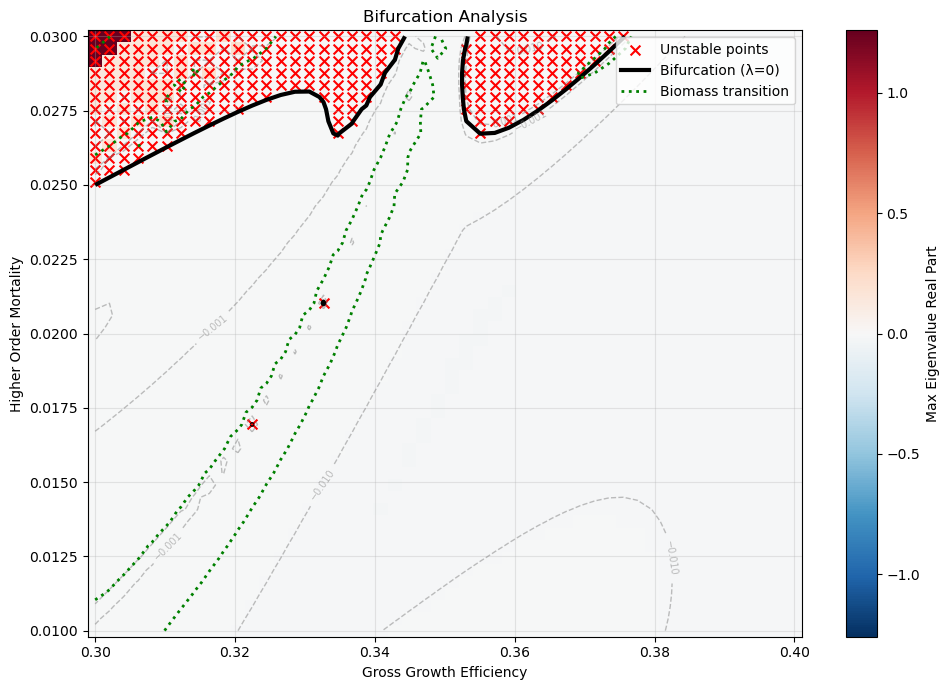

(<Figure size 1000x700 with 2 Axes>,
 <Axes: title={'center': 'Bifurcation Analysis'}, xlabel='Gross Growth Efficiency', ylabel='Higher Order Mortality'>)

In [30]:
plot_bifurcation_from_eigenvalues(stability_results_initcond, ivp_results)

Max eigenvalue range: -0.022656 to 1.260080
NaN count: 0/2500


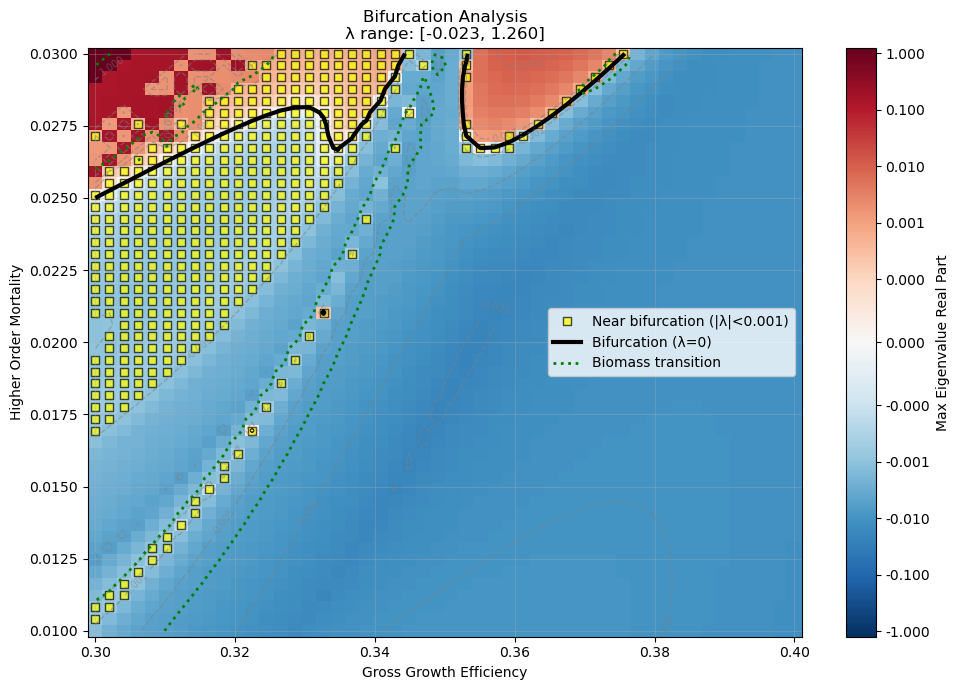

In [32]:
import matplotlib.pyplot as plt
import numpy as np

def plot_bifurcation_from_eigenvalues(ds, ivp_results=None, title='Bifurcation Analysis'):
    """
    Plot mathematically rigorous bifurcation boundaries using eigenvalues
    """
    fig, ax = plt.subplots(1, 1, figsize=(10, 7))
    
    # Plot max eigenvalue field
    max_eig = ds['max_eigenvalue'].values.T
    
    # Debug: check the data
    print(f"Max eigenvalue range: {np.nanmin(max_eig):.6f} to {np.nanmax(max_eig):.6f}")
    print(f"NaN count: {np.sum(np.isnan(max_eig))}/{max_eig.size}")
    
    # Create mesh
    X, Y = np.meshgrid(ds['GGE__gge'].values, ds['HigherOrderMortality__rate'].values)
    
    # Use symmetric log scale for better visualization
    # This handles the asymmetric range better
    from matplotlib.colors import SymLogNorm
    
    # Find appropriate scale
    vmax = max(abs(np.nanmin(max_eig)), abs(np.nanmax(max_eig)))
    linthresh = 1e-4  # Linear threshold near zero
    
    # Plot eigenvalue field with diverging colormap
    im = ax.pcolormesh(
        X, Y, max_eig,
        cmap='RdBu_r',  # Red for positive (unstable), Blue for negative (stable)
        norm=SymLogNorm(linthresh=linthresh, vmin=-vmax, vmax=vmax),
        shading='nearest'
    )
    
    # TRUE BIFURCATION: Contour at max eigenvalue = 0
    bifurcation = ax.contour(
        X, Y, max_eig,
        levels=[0],
        colors='black',
        linewidths=3
    )
    
    # Add other eigenvalue contours for context
    # Use log-spaced levels for better visualization
    pos_levels = [0.001, 0.01, 0.1, 1.0]
    neg_levels = [-0.02, -0.01, -0.005, -0.001]
    
    other_levels = ax.contour(
        X, Y, max_eig,
        levels=neg_levels + pos_levels,
        colors='gray',
        linewidths=1,
        linestyles='--',
        alpha=0.5
    )
    ax.clabel(other_levels, inline=True, fontsize=7, fmt='%.3f')
    
    # If IVP results provided, overlay biomass threshold
    if ivp_results is not None:
        phyto_last1000 = ivp_results['Phytoplankton__biomass'].isel(time=slice(-1000, None))
        phyto_total = phyto_last1000.sum(dim='phyto').mean(dim='time')
        
        # Find gradient to identify sharp transitions
        grad_x = np.gradient(phyto_total.values, axis=0)
        grad_y = np.gradient(phyto_total.values, axis=1)
        grad_mag = np.sqrt(grad_x**2 + grad_y**2)
        
        # Overlay biomass transition as dotted contours
        biomass_transition = ax.contour(
            X, Y, grad_mag.T,
            levels=[np.nanpercentile(grad_mag, 90)],
            colors='green',
            linewidths=2,
            linestyles=':'
        )
    
    cbar = plt.colorbar(im, ax=ax, format='%.3f')
    cbar.set_label('Max Eigenvalue Real Part')
    
    # Mark specific regions
    unstable_mask = max_eig > 0
    marginally_stable = np.abs(max_eig) < 0.001
    
    # Highlight marginally stable points
    if np.any(marginally_stable):
        ax.scatter(X[marginally_stable], Y[marginally_stable], 
                   marker='s', color='yellow', s=30, alpha=0.7, 
                   edgecolors='black', linewidths=1, label='Near bifurcation (|λ|<0.001)')
    
    # Add legend
    ax.plot([], [], 'k-', linewidth=3, label='Bifurcation (λ=0)')
    if ivp_results is not None:
        ax.plot([], [], 'g:', linewidth=2, label='Biomass transition')
    
    ax.set_xlabel('Gross Growth Efficiency')
    ax.set_ylabel('Higher Order Mortality')
    ax.set_title(title + f'\nλ range: [{np.nanmin(max_eig):.3f}, {np.nanmax(max_eig):.3f}]')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return fig, ax

# Call it
fig, ax = plot_bifurcation_from_eigenvalues(stability_results_initcond, ivp_results)

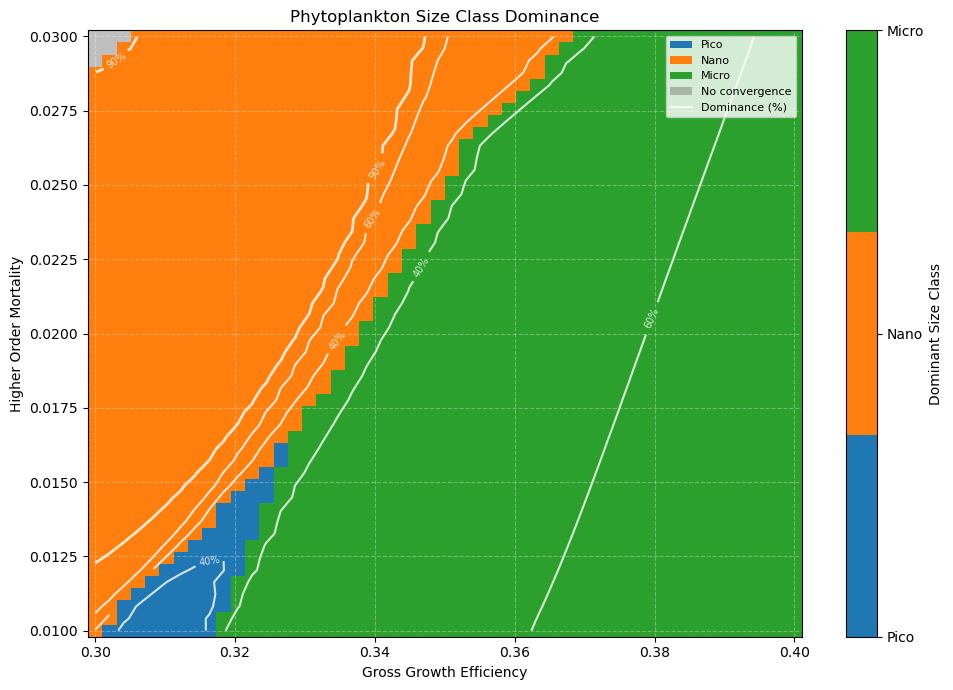

In [47]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.colors import ListedColormap
from scipy.ndimage import gaussian_filter

def plot_size_dominance(ivp_results, title='Phytoplankton Size Class Dominance'):
    """
    Plot which phytoplankton size class dominates across parameter space
    with contours showing strength of dominance within each region
    """
    # Get seaborn's default color palette (matches boxplot colors)
    palette = sns.color_palette()
    colors = [palette[0], palette[1], palette[2]]  # Blue, Orange, Green
    
    # Extract last 1000 days of phytoplankton biomass
    phyto_last1000 = ivp_results['Phytoplankton__biomass'].isel(time=slice(-1000, None))
    
    # Calculate mean biomass for each size class
    phyto_mean = phyto_last1000.mean(dim='time')
    
    # Find dominant size class and dominance strength at each grid point
    dominant_class = np.full((len(ivp_results['GGE__gge']), 
                              len(ivp_results['HigherOrderMortality__rate'])), 
                             np.nan)
    
    dominance_strength = np.full((len(ivp_results['GGE__gge']), 
                                   len(ivp_results['HigherOrderMortality__rate'])), 
                                  np.nan)
    
    # Also store dominance strength for each specific class
    pico_dominance = np.full_like(dominance_strength, np.nan)
    nano_dominance = np.full_like(dominance_strength, np.nan)
    micro_dominance = np.full_like(dominance_strength, np.nan)
    
    for i in range(len(ivp_results['GGE__gge'])):
        for j in range(len(ivp_results['HigherOrderMortality__rate'])):
            biomass_values = phyto_mean[i, j, :].values
            if not np.all(np.isnan(biomass_values)):
                # Find dominant class
                dominant_idx = np.nanargmax(biomass_values)
                dominant_class[i, j] = dominant_idx
                
                # Calculate dominance strength
                total = np.nansum(biomass_values)
                if total > 0:
                    dominance_value = biomass_values[dominant_idx] / total
                    dominance_strength[i, j] = dominance_value
                    
                    # Store in appropriate class-specific array
                    if dominant_idx == 0:
                        pico_dominance[i, j] = dominance_value
                    elif dominant_idx == 1:
                        nano_dominance[i, j] = dominance_value
                    elif dominant_idx == 2:
                        micro_dominance[i, j] = dominance_value
    
    # Create figure
    fig, ax = plt.subplots(1, 1, figsize=(10, 7))
    
    # Create custom colormap with seaborn colors
    cmap = ListedColormap(colors)
    cmap.set_bad(color='grey', alpha=0.5)
    
    # Plot dominance map
    X, Y = np.meshgrid(ivp_results['GGE__gge'].values, 
                       ivp_results['HigherOrderMortality__rate'].values)
    
    # Mask NaN values
    dominant_masked = np.ma.masked_invalid(dominant_class.T)
    
    im = ax.pcolormesh(
        X, Y, dominant_masked,
        cmap=cmap,
        vmin=0, vmax=2,
        shading='nearest'
    )
    
    # Add contours for dominance strength - separate for each class
    contour_levels = [0.1, 0.4, 0.6, 0.9]  # Adjusted levels for better visibility
    
    # Smooth each dominance field slightly for better contours
    sigma = 0.5  # Small smoothing parameter
    
    # Plot contours for each size class separately
    for idx, (dom_field, color_name) in enumerate([
        (pico_dominance, 'white'),
        (nano_dominance, 'white'), 
        (micro_dominance, 'white')
    ]):
        # Skip if no data for this class
        if np.all(np.isnan(dom_field)):
            continue
            
        # Apply light smoothing while preserving NaN structure
        dom_field_smooth = dom_field.copy()
        valid_mask = ~np.isnan(dom_field)
        if np.any(valid_mask):
            # Fill NaN with 0 for smoothing, then restore NaN
            dom_filled = np.where(np.isnan(dom_field), 0, dom_field)
            dom_smooth = gaussian_filter(dom_filled, sigma=sigma)
            # Only keep smoothed values where original was valid
            dom_field_smooth = np.where(valid_mask, dom_smooth, np.nan)
        
        # Mask invalid values for contour
        dom_masked = np.ma.masked_invalid(dom_field_smooth.T)
        
        if np.any(~np.isnan(dom_field_smooth)):
            try:
                contours = ax.contour(
                    X, Y, dom_masked,
                    levels=contour_levels,
                    colors=color_name,
                    linewidths=[1.0, 1.5, 1.5, 2.0],  # Varying line widths
                    alpha=0.8
                )
                
                # Label the contours
                ax.clabel(contours, inline=True, fontsize=7, 
                         fmt=lambda x: f'{int(x*100)}%')
            except:
                print(f"Could not draw contours for class {idx}")
    
    # Add colorbar with custom labels
    cbar = plt.colorbar(im, ax=ax, ticks=[0, 1, 2])
    cbar.ax.set_yticklabels(['Pico', 'Nano', 'Micro'])
    cbar.set_label('Dominant Size Class')
    
    # Add legend
    from matplotlib.patches import Patch
    from matplotlib.lines import Line2D
    
    legend_elements = [
        Patch(facecolor=colors[0], label='Pico'),
        Patch(facecolor=colors[1], label='Nano'),
        Patch(facecolor=colors[2], label='Micro'),
        Patch(facecolor='grey', alpha=0.5, label='No convergence'),
        Line2D([0], [0], color='white', linewidth=1.5, alpha=0.8, 
               label='Dominance (%)'),

    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=8)
    
    ax.set_xlabel('Gross Growth Efficiency')
    ax.set_ylabel('Higher Order Mortality')
    ax.set_title(title)
    ax.grid(True, alpha=0.3, linestyle='--', color='white')
    
    plt.tight_layout()
    plt.show()
    
    return fig, ax

# Use it
fig, ax = plot_size_dominance(ivp_results)